In [3]:
from google.colab import files

uploaded = files.upload()

Saving marketing_data_dictionary.csv to marketing_data_dictionary (1).csv


In [5]:
from google.colab import files

uploaded = files.upload()

Saving marketing_campaign_data.csv to marketing_campaign_data (1).csv


In [6]:
import os
print(os.listdir())

['.config', 'marketing_campaign_data (1).csv', 'marketing_data_dictionary (1).csv', 'marketing_campaign_data.csv', 'marketing_data_dictionary.csv', 'sample_data']


In [7]:
import pandas as pd

df = pd.read_csv("marketing_campaign_data.csv")

print(df.shape)

df.head()

(56000, 28)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada


In [8]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Response',
 'Complain',
 'Country']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  object 
 3   Marital_Status       56000 non-null  object 
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  object 
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null 

In [10]:
# Missing values

df.isnull().sum()

# Fill missing values

for col in df.columns:

    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])

    else:
        df[col] = df[col].fillna(df[col].median())

print("Missing values handled")

Missing values handled


In [11]:
# Age

df["Age"] = 2026 - df["Year_Birth"]

# Children

df["Children"] = df["Kidhome"] + df["Teenhome"]

# Total Spend

df["Total_Spend"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

# Total Purchases

df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

print("Features Created Successfully")

Features Created Successfully


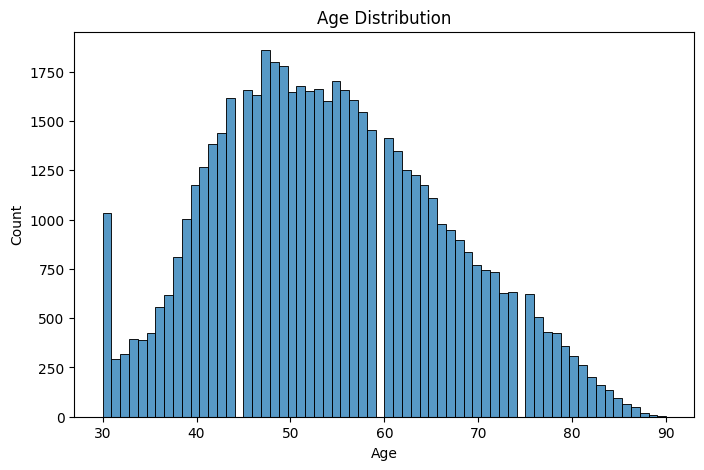

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Age"])
plt.title("Age Distribution")
plt.show()

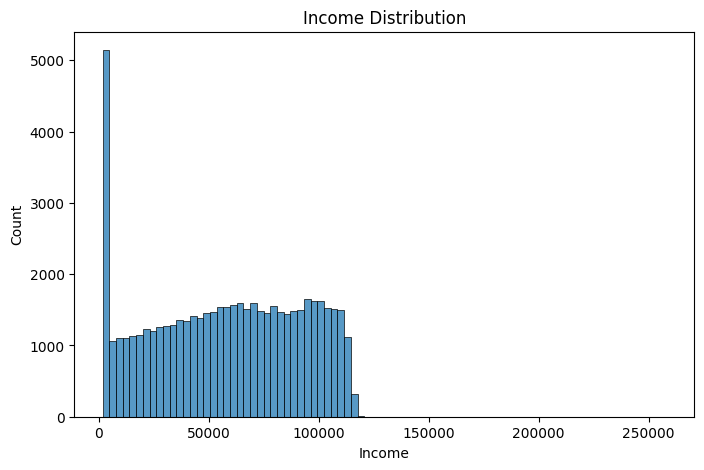

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Income"])
plt.title("Income Distribution")
plt.show()

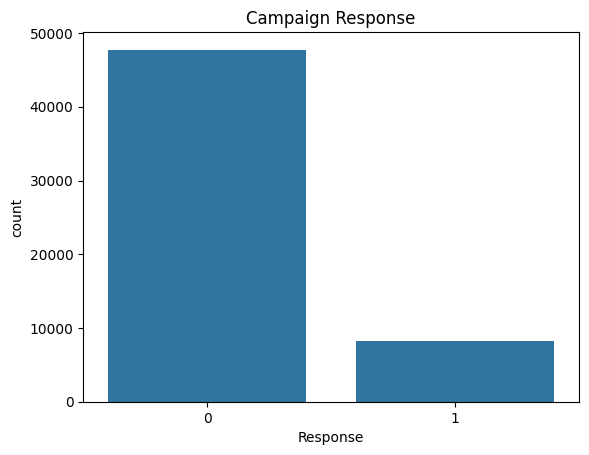

In [14]:
sns.countplot(x="Response", data=df)
plt.title("Campaign Response")
plt.show()

In [15]:
df["Income_Segment"] = pd.cut(
    df["Income"],
    bins=[0,30000,60000,1000000],
    labels=["Low","Medium","High"]
)

threshold = df["Total_Spend"].quantile(0.90)

df["High_Spender"] = (
    df["Total_Spend"] > threshold
).astype(int)

df["High_Web_Engagement"] = (
    df["NumWebVisitsMonth"] > 5
).astype(int)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Complain,Country,Age,Children,Total_Spend,Total_Purchases,Income_Segment,High_Spender,High_Web_Engagement
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,0,0,Spain,41,1,69,10,Medium,0,0
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,0,Spain,51,2,39,3,Low,0,0
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,0,0,Australia,48,0,1512,9,High,0,0
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,0,0,Spain,50,1,478,15,High,0,0
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,0,0,Canada,45,2,330,8,Medium,0,1


In [16]:
df.to_csv(
    "marketing_cleaned.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


In [22]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Response',
 'Complain',
 'Country',
 'Age',
 'Children',
 'Total_Spend',
 'Total_Purchases',
 'Income_Segment',
 'High_Spender',
 'High_Web_Engagement']